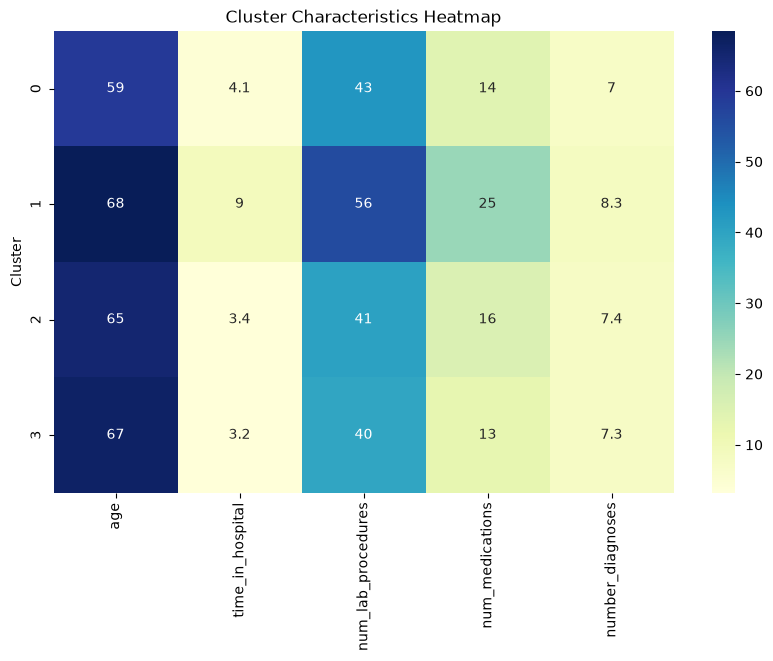

In [8]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="YlGnBu"
)

plt.title("Cluster Characteristics Heatmap")
plt.show()

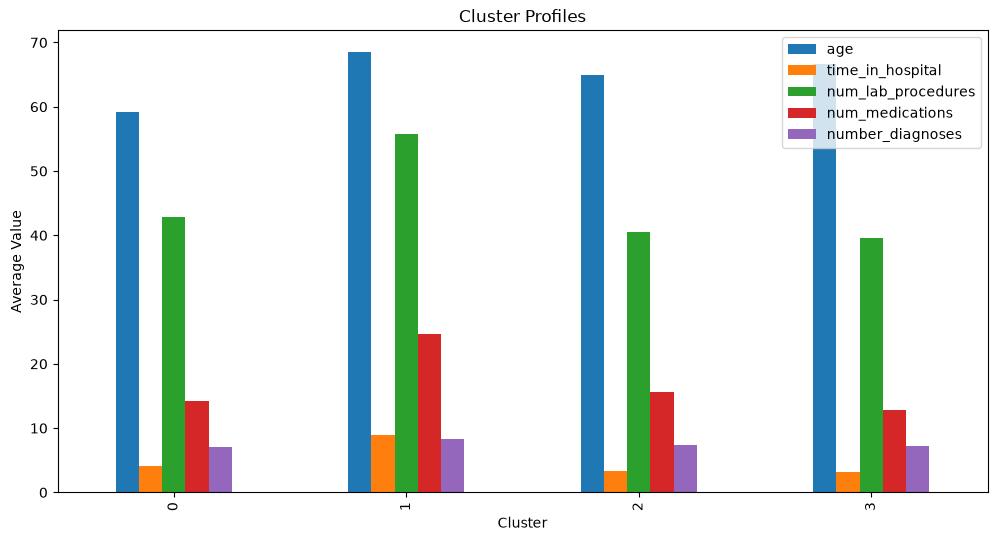

In [7]:
cluster_profile = df.groupby("Cluster")[[
    "age",
    "time_in_hospital",
    "num_lab_procedures",
    "num_medications",
    "number_diagnoses"
]].mean()

cluster_profile.plot(
    kind="bar",
    figsize=(12,6)
)
plt.title("Cluster Profiles")
plt.ylabel("Average Value")
plt.show()

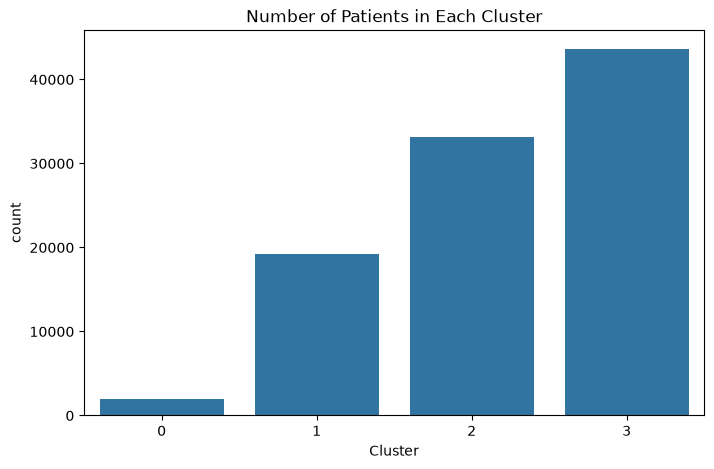

In [6]:
plt.figure(figsize=(8,5))
sns.countplot(x='Cluster', data=df)
plt.title("Number of Patients in Each Cluster")
plt.show()

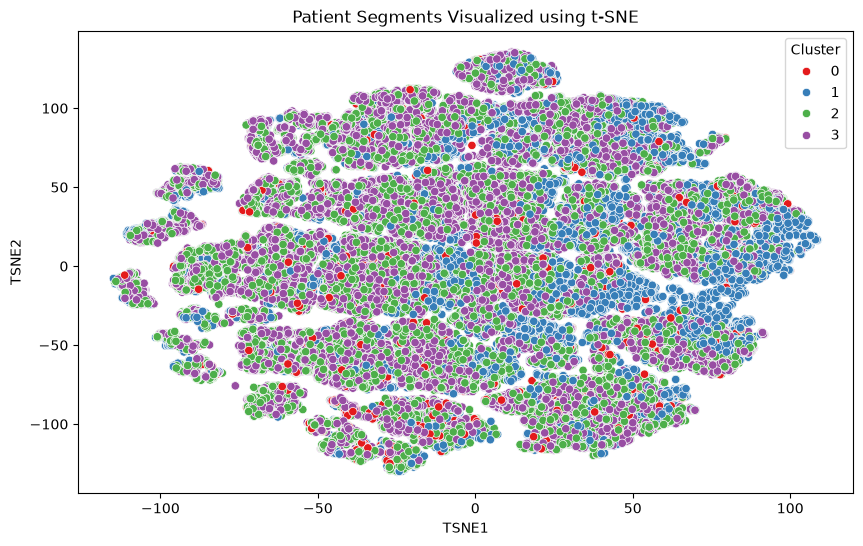

In [5]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_tsne = tsne.fit_transform(X)

tsne_df = pd.DataFrame({
    'TSNE1': X_tsne[:,0],
    'TSNE2': X_tsne[:,1],
    'Cluster': y
})

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=tsne_df,
    x='TSNE1',
    y='TSNE2',
    hue='Cluster',
    palette='Set1'
)
plt.title("Patient Segments Visualized using t-SNE")
plt.show()

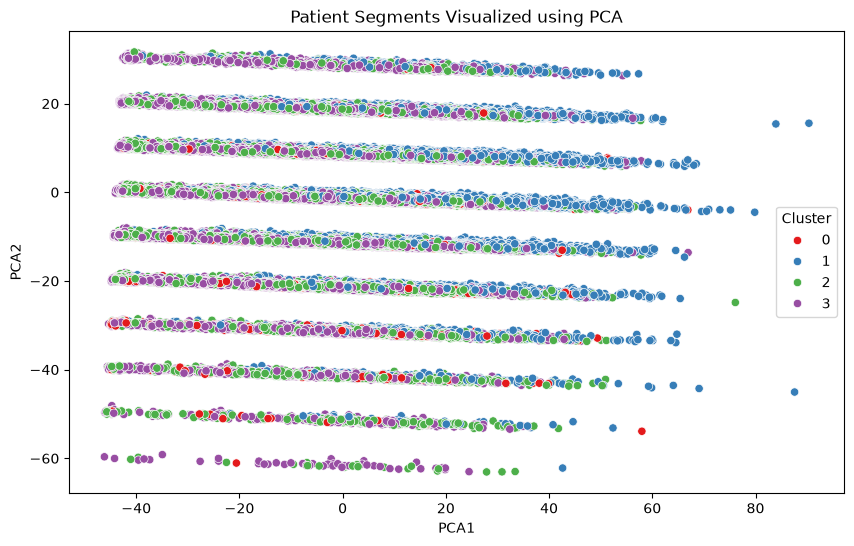

In [4]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame({
    'PCA1': X_pca[:,0],
    'PCA2': X_pca[:,1],
    'Cluster': y
})

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=pca_df,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='Set1'
)
plt.title("Patient Segments Visualized using PCA")
plt.show()

In [3]:
X = df.drop("Cluster", axis=1)
y = df["Cluster"]

In [2]:
import pandas as pd

df = pd.read_csv("final_dataset_clustered.csv")

print(df.head())
print(df["Cluster"].value_counts())

   age  admission_type_id  discharge_disposition_id  admission_source_id  \
0   15                  1                         1                    7   
1   25                  1                         1                    7   
2   35                  1                         1                    7   
3   45                  1                         1                    7   
4   55                  2                         1                    2   

   time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
0                 3                  59               0               18   
1                 2                  11               5               13   
2                 2                  44               1               16   
3                 1                  51               0                8   
4                 3                  31               6               16   

   number_outpatient  number_emergency  ...  department_Surgery  \
0                  